In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q timm peft scikit-learn

Mounted at /content/drive


In [ ]:
import json, pickle, itertools, random, shutil, re
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets
from scipy.stats import binomtest
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

PROJECT_DIR = Path('/content/drive/MyDrive/Indian_Food_Research')
DATASET_PATH = PROJECT_DIR / 'datasets' / 'CompressedDataset'
SPLITS_DIR, RESULTS_DIR, REPORTS_DIR = PROJECT_DIR / 'splits', PROJECT_DIR / 'results', PROJECT_DIR / 'reports'
MS_DIR = RESULTS_DIR / 'multiseed'
TABLES = RESULTS_DIR / 'revision_tables'; TABLES.mkdir(parents=True, exist_ok=True)
PKG = PROJECT_DIR / 'repro_package'; PKG.mkdir(exist_ok=True)

full_ds = datasets.ImageFolder(str(DATASET_PATH))
class_names = full_ds.classes
assert len(class_names) == 100 and len(full_ds.samples) == 4578
targets = np.array(full_ds.targets)
train_idx = pickle.load(open(SPLITS_DIR / 'train_idx.pkl', 'rb'))
val_idx   = pickle.load(open(SPLITS_DIR / 'val_idx.pkl',   'rb'))
test_idx  = pickle.load(open(SPLITS_DIR / 'test_idx.pkl',  'rb'))
split_of = np.array(['excluded'] * len(targets), dtype=object)
for n, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    split_of[list(idx)] = n

ORDER = ['resnet50_scratch', 'linear_probe', 'lora', 'full_finetune']
NICE = {'resnet50_scratch': 'ResNet-50 (scratch)', 'linear_probe': 'DINOv2 linear probe',
        'lora': 'DINOv2 + LoRA (r=8)', 'full_finetune': 'DINOv2 full fine-tuning'}
runs = []
for f in sorted(MS_DIR.glob('*.npz')):
    z = np.load(f, allow_pickle=False); meta = json.loads(str(z['meta']))
    runs.append({**meta, 'pred': z['test_pred'], 'true': z['test_true']})
R = pd.DataFrame(runs)
print(R.groupby(['method', 'fraction']).seed.apply(lambda s: sorted(s.tolist())).to_string())

method            fraction
full_finetune     0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
linear_probe      0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
lora              0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
lora_r16          1.00        [0, 1, 2]
lora_r4           1.00        [0, 1, 2]
resnet50_scratch  0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]


{
  "images_collected": 4578,
  "exact_duplicate_groups": 84,
  "removed_extra_copies_same_class": 73,
  "removed_cross_class_duplicates": 22,
  "images_used": 4483,
  "near_duplicate_groups_kept_together": 210,
  "images_in_near_duplicate_groups": 497,
  "largest_group": 17,
  "near_duplicate_groups_spanning_classes": 3,
  "thresholds": {
    "phash_hamming_max": 6,
    "dinov2_cosine_min": 0.95
  },
  "per_class_used_min": 7
}


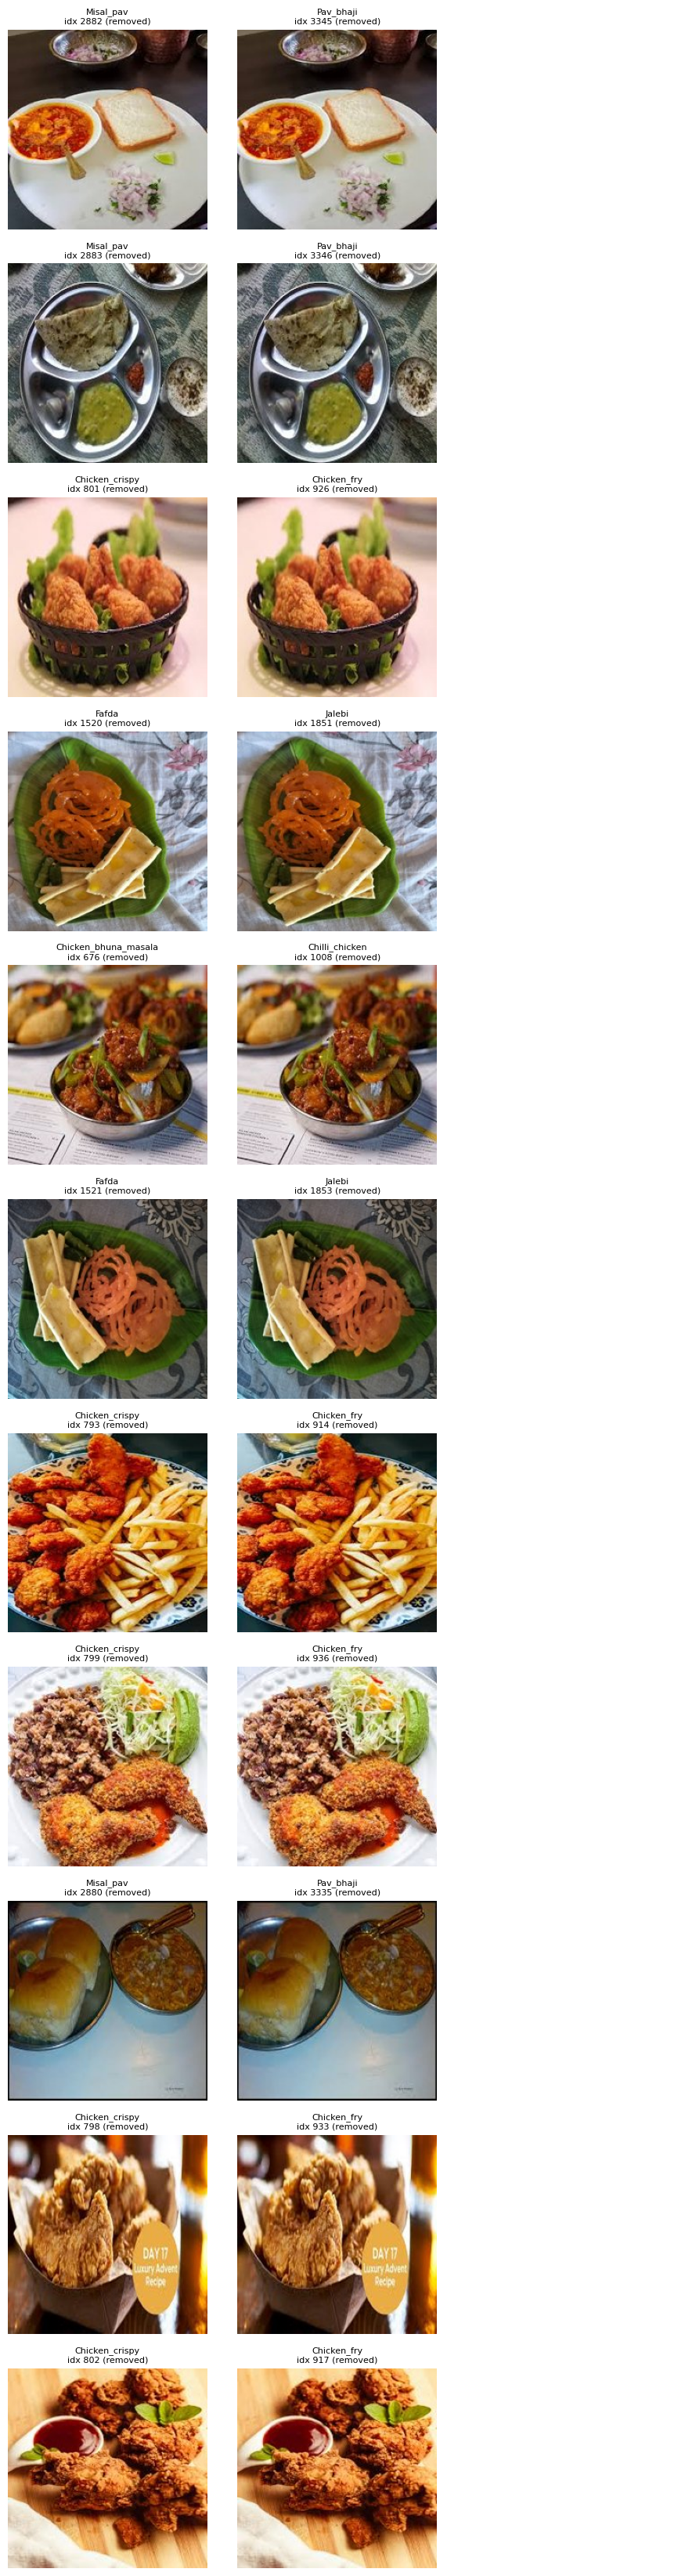

95 images not in any split; 95 listed in the duplicate report


In [ ]:
dedup = json.loads((REPORTS_DIR / 'dedup_summary.json').read_text())
print(json.dumps(dedup, indent=2))
allx = pd.read_csv(REPORTS_DIR / 'exact_duplicate_groups_all.csv')
cc = allx.groupby('md5').filter(lambda g: g['label'].nunique() > 1).sort_values(['md5', 'class'])
groups = list(cc.groupby('md5'))
if groups:
    fig, axes = plt.subplots(len(groups), 3, figsize=(9, 3 * len(groups)), squeeze=False)
    for i, (h, g) in enumerate(groups):
        for j in range(3):
            axes[i, j].axis('off')
        for j, (_, r) in enumerate(g.iterrows()):
            if j < 3:
                axes[i, j].imshow(Image.open(r['path'])); axes[i, j].set_title(f"{r['class']}\nidx {r['idx']} (removed)", fontsize=8)
    plt.tight_layout(); plt.savefig(REPORTS_DIR / 'cross_class_duplicates_removed.png', dpi=150); plt.show()
excluded_reason = dict(zip(allx[allx.removed].idx.astype(int), allx[allx.removed].reason))
print(split_of.tolist().count('excluded'), 'images not in any split;', len(excluded_reason), 'listed in the duplicate report')

fractions available: [np.float64(1.0), np.float64(0.5), np.float64(0.25), np.float64(0.1)] (expect [1.0, 0.5, 0.25, 0.1] — otherwise re-run notebook 07)
 Labels (%)                  Method  n seeds  n train        Top-1     Macro-F1
        100     ResNet-50 (scratch)        3     3127 63.77 ± 3.04 60.46 ± 3.00
        100     DINOv2 linear probe        3     3127 94.15 ± 0.09 93.78 ± 0.63
        100     DINOv2 + LoRA (r=8)        3     3127 95.92 ± 0.45 94.67 ± 0.99
        100 DINOv2 full fine-tuning        3     3127 94.49 ± 1.49 93.18 ± 1.30
         50     ResNet-50 (scratch)        3     1565 43.51 ± 2.17 37.50 ± 2.21
         50     DINOv2 linear probe        3     1565 92.67 ± 0.23 92.13 ± 0.28
         50     DINOv2 + LoRA (r=8)        3     1565 94.15 ± 0.45 92.98 ± 1.28
         50 DINOv2 full fine-tuning        3     1565 91.30 ± 0.90 88.73 ± 2.22
         25     ResNet-50 (scratch)        3      782 20.89 ± 2.98 14.48 ± 2.20
         25     DINOv2 linear probe        3   

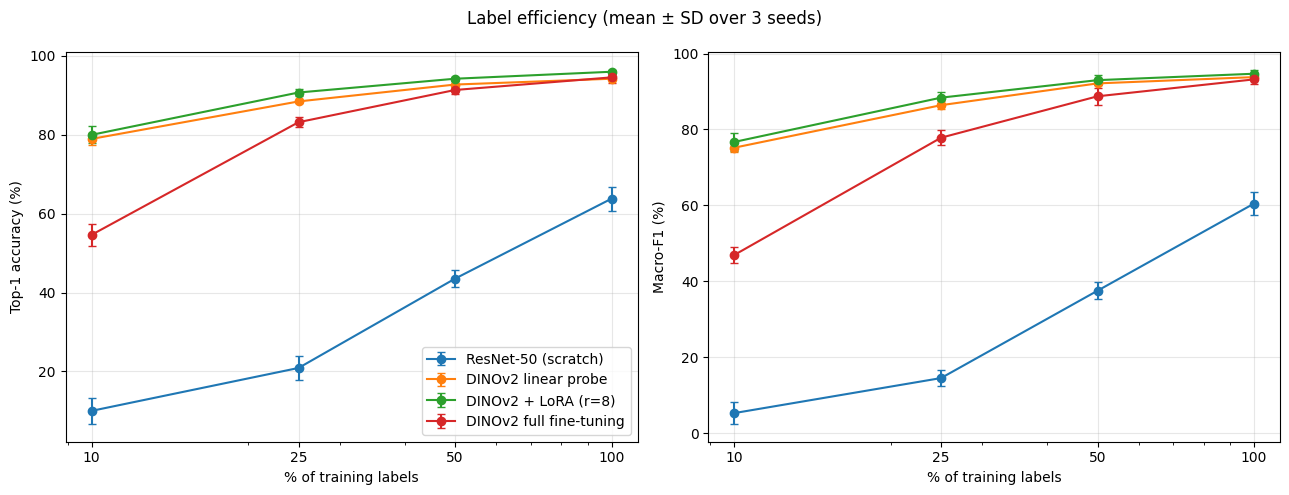

In [ ]:
def holm(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p); adj = np.empty(m); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * p[i]); adj[i] = min(1.0, run)
    return adj

M = pd.DataFrame([{'method': r.method, 'fraction': r.fraction, 'seed': r.seed, 'n_train': r.n_train,
                   'top1': 100 * accuracy_score(r.true, r.pred),
                   'macro_f1': 100 * f1_score(r.true, r.pred, labels=range(100), average='macro', zero_division=0)}
                  for r in R.itertuples()])
fracs = sorted(M.fraction.unique(), reverse=True)
print('fractions available:', fracs, '(expect [1.0, 0.5, 0.25, 0.1] — otherwise re-run notebook 07)')

tab = []
for fr in fracs:
    for m in ORDER:
        g = M[(M.method == m) & (M.fraction == fr)]
        if g.empty: continue
        tab.append({'Labels (%)': int(round(100 * fr)), 'Method': NICE[m], 'n seeds': len(g), 'n train': int(g.n_train.iloc[0]),
                    'Top-1': f'{g.top1.mean():.2f} ± {g.top1.std(ddof=1):.2f}',
                    'Macro-F1': f'{g.macro_f1.mean():.2f} ± {g.macro_f1.std(ddof=1):.2f}'})
LE = pd.DataFrame(tab); LE.to_csv(TABLES / 'table_label_efficiency_mean_sd.csv', index=False)
print(LE.to_string(index=False))

ytr = targets[list(train_idx)]
for fr in fracs:
    cnt = Counter(ytr)
    n_c = {c: min(n, max(1, round(fr * n))) for c, n in cnt.items()}
    print(f'{int(100*fr):3d}% labels: {sum(n_c.values())} images, per class min {min(n_c.values())} median {int(np.median(list(n_c.values())))} max {max(n_c.values())}')

PAIRS = [('lora', 'linear_probe'), ('lora', 'full_finetune'), ('linear_probe', 'full_finetune')]
C = {(r.method, r.fraction, r.seed): (r.pred == r.true) for r in R.itertuples()}
rows = []
for fr in fracs:
    for s in sorted(M.seed.unique()):
        block = []
        for a, b in PAIRS:
            if (a, fr, s) not in C or (b, fr, s) not in C: continue
            ca, cb = C[a, fr, s], C[b, fr, s]
            n10, n01 = int((ca & ~cb).sum()), int((~ca & cb).sum())
            block.append({'Labels (%)': int(round(100 * fr)), 'seed': s, 'A': NICE[a], 'B': NICE[b], 'A only': n10, 'B only': n01,
                          'delta_pp': round(100 * (ca.mean() - cb.mean()), 2),
                          'p_exact': 1.0 if n10 + n01 == 0 else binomtest(n10, n10 + n01, 0.5).pvalue})
        for r, q in zip(block, holm([r['p_exact'] for r in block])):
            r['p_holm'] = q; r['significant@0.05'] = q < 0.05
        rows += block
LM = pd.DataFrame(rows); LM.to_csv(TABLES / 'table_label_efficiency_mcnemar.csv', index=False)

rng = np.random.default_rng(0); B = 10000
brow = []
for fr in fracs:
    for a, b in PAIRS:
        sa = [C[a, fr, s] for s in sorted(M.seed.unique()) if (a, fr, s) in C]
        sb = [C[b, fr, s] for s in sorted(M.seed.unique()) if (b, fr, s) in C]
        if not sa or not sb: continue
        d = np.mean(sa, 0) - np.mean(sb, 0)
        bs = d[rng.integers(0, len(d), (B, len(d)))].mean(1)
        lo, hi = np.percentile(bs, [2.5, 97.5])
        brow.append({'Labels (%)': int(round(100 * fr)), 'A': NICE[a], 'B': NICE[b], 'delta_pp': round(100 * d.mean(), 2),
                     'CI low': round(100 * lo, 2), 'CI high': round(100 * hi, 2), 'CI excludes 0': bool(lo > 0 or hi < 0),
                     'McNemar sig. seeds (Holm)': int(LM[(LM['Labels (%)'] == int(round(100*fr))) & (LM.A == NICE[a]) & (LM.B == NICE[b])]['significant@0.05'].sum())})
LB = pd.DataFrame(brow); LB.to_csv(TABLES / 'table_label_efficiency_paired_bootstrap.csv', index=False)
print('\nSeed-averaged paired bootstrap (test-image resampling; reflects test-set uncertainty only):\n', LB.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for m in ORDER:
    g = M[M.method == m].groupby('fraction')
    for k, col in enumerate(['top1', 'macro_f1']):
        ax[k].errorbar(100 * g[col].mean().index, g[col].mean(), yerr=g[col].std(ddof=1), marker='o', capsize=3, label=NICE[m])
for k, lab in enumerate(['Top-1 accuracy (%)', 'Macro-F1 (%)']):
    ax[k].set_xlabel('% of training labels'); ax[k].set_ylabel(lab); ax[k].set_xscale('log')
    ax[k].set_xticks([10, 25, 50, 100]); ax[k].set_xticklabels(['10', '25', '50', '100']); ax[k].grid(alpha=.3)
ax[0].legend(); fig.suptitle('Label efficiency (mean ± SD over 3 seeds)')
plt.tight_layout(); plt.savefig(TABLES / 'fig_label_efficiency_mean_sd.png', dpi=300); plt.savefig(TABLES / 'fig_label_efficiency_mean_sd.pdf'); plt.show()

In [ ]:
ABL = {'lora_r4': 4, 'lora': 8, 'lora_r16': 16}
arows = []
for m, r in ABL.items():
    g = M[(M.method == m) & (M.fraction == 1.0)]
    if g.empty: print('missing', m, '- run notebook 07'); continue
    tp = int(R[(R.method == m) & (R.fraction == 1.0)].trainable_params.iloc[0])
    tot = int(R[(R.method == m) & (R.fraction == 1.0)].total_params.iloc[0])
    arows.append({'Rank r': r, 'Trainable params': tp, 'Trainable (%)': round(100 * tp / tot, 3), 'n seeds': len(g),
                  'Top-1': f'{g.top1.mean():.2f} ± {g.top1.std(ddof=1):.2f}', 'Macro-F1': f'{g.macro_f1.mean():.2f} ± {g.macro_f1.std(ddof=1):.2f}'})
AB = pd.DataFrame(arows); AB.to_csv(TABLES / 'table_lora_rank_ablation_mean_sd.csv', index=False)
print(AB.to_string(index=False))
rows = []
for s_ in sorted(M.seed.unique()):
    block = []
    for a, b in itertools.combinations(ABL, 2):
        if (a, 1.0, s_) not in C or (b, 1.0, s_) not in C: continue
        ca, cb = C[a, 1.0, s_], C[b, 1.0, s_]
        n10, n01 = int((ca & ~cb).sum()), int((~ca & cb).sum())
        block.append({'seed': s_, 'A': f'r={ABL[a]}', 'B': f'r={ABL[b]}', 'delta_pp': round(100 * (ca.mean() - cb.mean()), 2),
                      'p_exact': 1.0 if n10 + n01 == 0 else binomtest(n10, n10 + n01, 0.5).pvalue})
    for r_, q in zip(block, holm([r_['p_exact'] for r_ in block])):
        r_['p_holm'] = q; r_['significant@0.05'] = q < 0.05
    rows += block
pd.DataFrame(rows).to_csv(TABLES / 'table_lora_rank_ablation_mcnemar.csv', index=False)
print(pd.DataFrame(rows).round(4).to_string(index=False))

 Rank r  Trainable params  Trainable (%)  n seeds        Top-1     Macro-F1
      4            224356          0.261        3 95.58 ± 0.29 94.41 ± 1.05
      8            371812          0.431        3 95.92 ± 0.45 94.67 ± 0.99
     16            666724          0.771        3 95.67 ± 0.23 94.40 ± 0.29
 seed   A    B  delta_pp  p_exact  p_holm  significant@0.05
    0 r=4  r=8     -0.15   1.0000  1.0000             False
    0 r=4 r=16     -0.44   0.5078  1.0000             False
    0 r=8 r=16     -0.29   0.7266  1.0000             False
    1 r=4  r=8     -0.44   0.4531  1.0000             False
    1 r=4 r=16     -0.29   0.7266  1.0000             False
    1 r=8 r=16      0.15   1.0000  1.0000             False
    2 r=4  r=8     -0.44   0.5488  1.0000             False
    2 r=4 r=16      0.44   0.5078  1.0000             False
    2 r=8 r=16      0.88   0.1796  0.5387             False


In [ ]:
!pip install -q -U "torchao>=0.16"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.4 MB/s eta 0:00:00


In [ ]:
import torch, timm
from peft import LoraConfig, get_peft_model
m = timm.create_model('vit_base_patch14_dinov2', pretrained=True, num_classes=100, img_size=224)
details = {'timm_name': 'vit_base_patch14_dinov2', 'hf_hub_id': str(m.pretrained_cfg.get('hf_hub_id')),
           'native_input_size': str(m.pretrained_cfg.get('input_size')), 'used_input_size': '224x224 (position embeddings interpolated by timm)',
           'patch_grid_at_224': str(m.patch_embed.grid_size), 'embed_dim': m.embed_dim, 'depth': len(m.blocks),
           'head': repr(m.head), 'head_init': 'timm default initialisation of a new nn.Linear(768, 100), on the CLS token (global_pool=token)',
           'global_pool': str(getattr(m, 'global_pool', '?'))}
pm = get_peft_model(m, LoraConfig(r=8, lora_alpha=16, target_modules=['qkv'], lora_dropout=0.1, modules_to_save=['head']))
lora_mods = sorted({n.split('.lora_A')[0] for n, _ in pm.named_parameters() if '.lora_A' in n})
n_lora = sum(p.numel() for n, p in pm.named_parameters() if p.requires_grad and 'lora_' in n)
n_head = sum(p.numel() for n, p in pm.named_parameters() if p.requires_grad and 'lora_' not in n)
n_all = sum(p.numel() for p in pm.parameters())
details.update({'lora': {'r': 8, 'alpha': 16, 'dropout': 0.1, 'target_modules': 'qkv (fused query/key/value projection) in all blocks',
                         'n_adapted_modules': len(lora_mods), 'adapted_modules': lora_mods,
                         'lora_params': n_lora, 'head_params': n_head, 'trainable_total': n_lora + n_head,
                         'trainable_pct_of_wrapped_model': round(100 * (n_lora + n_head) / n_all, 3)}})
(PKG / 'model_details.json').write_text(json.dumps(details, indent=2))
print(json.dumps({k: v for k, v in details.items() if k != 'lora'}, indent=1))
print({k: v for k, v in details['lora'].items() if k != 'adapted_modules'})
del m, pm

{
 "timm_name": "vit_base_patch14_dinov2",
 "hf_hub_id": "timm/vit_base_patch14_dinov2.lvd142m",
 "native_input_size": "(3, 518, 518)",
 "used_input_size": "224x224 (position embeddings interpolated by timm)",
 "patch_grid_at_224": "(16, 16)",
 "embed_dim": 768,
 "depth": 12,
 "head": "Linear(in_features=768, out_features=100, bias=True)",
 "head_init": "timm default initialisation of a new nn.Linear(768, 100), on the CLS token (global_pool=token)",
 "global_pool": "token"
}
{'r': 8, 'alpha': 16, 'dropout': 0.1, 'target_modules': 'qkv (fused query/key/value projection) in all blocks', 'n_adapted_modules': 12, 'lora_params': 294912, 'head_params': 76900, 'trainable_total': 371812, 'trainable_pct_of_wrapped_model': 0.431}


In [ ]:
cfg = {}
for r in R.itertuples():
    cfg.setdefault(r.method, {k: getattr(r, k) for k in ('epochs', 'lr', 'weight_decay', 'batch_size', 'lora', 'trainable_params', 'total_params')})

In [ ]:
used_mask = split_of != 'excluded'
pd.DataFrame({'label': range(100), 'class': class_names,
              'n_collected': np.bincount(targets, minlength=100),
              'n_used': np.bincount(targets[used_mask], minlength=100),
              'n_train': np.bincount(targets[list(train_idx)], minlength=100),
              'n_val': np.bincount(targets[list(val_idx)], minlength=100),
              'n_test': np.bincount(targets[list(test_idx)], minlength=100)}).to_csv(PKG / 'class_list.csv', index=False)
pos_in_split = {}
for n, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    for j, i in enumerate(idx): pos_in_split[int(i)] = j
pd.DataFrame({'global_index': range(len(targets)),
              'relative_path': [str(Path(p).relative_to(DATASET_PATH)) for p, _ in full_ds.samples],
              'label': targets, 'class': [class_names[t] for t in targets], 'split': split_of,
              'position_in_split': [pos_in_split.get(i, -1) for i in range(len(targets))],
              'excluded_reason': [excluded_reason.get(i, '') for i in range(len(targets))],
              'near_duplicate_group': json.loads((SPLITS_DIR / 'group_ids.json').read_text())}).to_csv(PKG / 'splits.csv', index=False)
for f in ['train_idx.pkl', 'val_idx.pkl', 'test_idx.pkl', 'flagged_test_indices.json', 'dedup_exclude.json', 'group_ids.json']:
    shutil.copy(SPLITS_DIR / f, PKG / f)

for r in R.itertuples():
    cfg.setdefault(r.method, {k: getattr(r, k) for k in ('epochs', 'lr', 'weight_decay', 'batch_size', 'lora', 'trainable_params', 'total_params')})
cfg = {k: {kk: (vv if not isinstance(vv, (np.integer, np.floating)) else vv.item()) for kk, vv in v.items()} for k, v in cfg.items()}
train_cfg = {'per_method': cfg,
             'optimizer': 'AdamW over trainable parameters only', 'scheduler': 'CosineAnnealingLR, T_max = epochs, stepped per epoch',
             'loss': 'cross-entropy', 'mixed_precision': 'torch.amp autocast fp16 + GradScaler',
             'input': '224x224, PIL bilinear resize (no crop), ImageNet mean/std normalisation',
             'augmentation': 'horizontal flip p=0.5; brightness, saturation and contrast factors each U(0.8, 1.2), applied in that order; clip to [0,255]',
             'checkpoint_selection': 'epoch with highest validation top-1 (strict >, earliest epoch on ties); test set evaluated once with that checkpoint',
             'seeds': sorted(int(s) for s in R.seed.unique()),
             'label_budget_sampling': 'per class n_c = max(1, round(f * N_c)) from the train split, random.Random(seed)'}
(PKG / 'training_config.json').write_text(json.dumps(train_cfg, indent=2, default=str))
for f in [MS_DIR / 'versions.json', RESULTS_DIR / 'zeroshot_v2' / 'versions.json']:
    if f.exists(): shutil.copy(f, PKG / f'versions_{f.parent.name}.json')

rows = []
for r in R.itertuples():
    for j, (t, p) in enumerate(zip(r.true, r.pred)):
        rows.append(('indian_test', j, int(test_idx[j]), r.method, int(r.seed), float(r.fraction), int(t), int(p)))
for f in sorted(RESULTS_DIR.glob('preds_indian_*.npy')) + sorted(RESULTS_DIR.glob('preds_western_*.npy')):
    a = np.load(f); ds = 'indian_test' if 'indian' in f.name else 'food101_matched_test'
    for j, (t, p) in enumerate(zip(a[0], a[1])):
        rows.append((ds, j, int(test_idx[j]) if ds == 'indian_test' else -1, 'zeroshot_' + f.stem.split('_', 2)[2], -1, 0.0, int(t), int(p)))
pd.DataFrame(rows, columns=['dataset', 'position', 'global_index', 'model', 'seed', 'label_fraction', 'true', 'pred']) \
  .to_csv(PKG / 'per_image_predictions.csv.gz', index=False, compression='gzip')
print(len(rows), 'prediction rows written')

for src in [REPORTS_DIR / 'dedup_summary.json', REPORTS_DIR / 'exact_duplicate_groups_all.csv',
            REPORTS_DIR / 'near_duplicate_groups.csv', REPORTS_DIR / 'duplicate_audit_summary.json', REPORTS_DIR / 'phash_threshold_sweep.csv',
            REPORTS_DIR / 'embedding_threshold_sweep.csv', RESULTS_DIR / 'zeroshot_v2' / 'prompt_templates.json',
            RESULTS_DIR / 'zeroshot_v2' / 'food101_matched_classes.csv', RESULTS_DIR / 'zeroshot_v2' / 'matched_sets_file_lists.csv',
            RESULTS_DIR / 'zeroshot_v2' / 'zeroshot_probe_results.json', RESULTS_DIR / 'robustness_v2' / 'corruption_parameters.json',
            RESULTS_DIR / 'robustness_v2' / 'robustness_per_image_predictions.npz', RESULTS_DIR / 'robustness_v2' / 'gradcam_details.json']:
    if src.exists(): shutil.copy(src, PKG / src.name)
    else: print('missing (run the notebook that makes it):', src.name)
print(sorted(p.name for p in PKG.iterdir()))

40680 prediction rows written
['class_list.csv', 'corruption_parameters.json', 'dedup_exclude.json', 'dedup_summary.json', 'duplicate_audit_summary.json', 'embedding_threshold_sweep.csv', 'exact_duplicate_groups_all.csv', 'flagged_test_indices.json', 'food101_matched_classes.csv', 'gradcam_details.json', 'group_ids.json', 'matched_sets_file_lists.csv', 'model_details.json', 'near_duplicate_groups.csv', 'per_image_predictions.csv.gz', 'phash_threshold_sweep.csv', 'prompt_templates.json', 'robustness_per_image_predictions.npz', 'splits.csv', 'test_idx.pkl', 'train_idx.pkl', 'training_config.json', 'val_idx.pkl', 'versions_multiseed.json', 'versions_zeroshot_v2.json', 'zeroshot_probe_results.json']
